In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV3Small
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# ignoring warnings
import warnings
warnings.simplefilter("ignore")

In [2]:
# Parámetros generales
image_height = 224
image_width = 224
batch_size = 32
epochs = 20
input_shape = (image_height, image_width, 3)
num_classes = None  # Se infiere del generador

data_dir = "Datos Finales Estado Balanceados"
metadata_file = "archivos_datos_balanceados_estado.csv"

df = pd.read_csv(metadata_file, sep=";")
df = df.rename(columns={'Nombre del archivo': 'image_id'})
df['Planta_Estado'] = df['Planta_Estado'].astype(str)

categoria = 'Planta_Estado'
image_id = 'image_id'

In [3]:
# Dividir en entrenamiento y validación
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df, test_size=0.2, stratify=df['Planta_Estado'], random_state=42)
train_df.shape, test_df.shape

((50400, 7), (12601, 7))

In [4]:
# Total de clases
print("Clases:", df['Planta_Estado'].nunique())
num_classes = df['Planta_Estado'].nunique()
class_names = df['Planta_Estado'].unique().tolist()
print(class_names)

Clases: 18
['Maíz_Enferma', 'Tomate_Saludable', 'Yuca_Enferma', 'Pepino Cohombro_Enferma', 'Tomate_Enferma', 'Manzana_Saludable', 'Fresa_Enferma', 'Maíz_Saludable', 'Papa_Enferma', 'Fresa_Saludable', 'Coliflor_Enferma', 'Pepino Cohombro_Saludable', 'Yuca_Saludable', 'Fríjol_Enferma', 'Papa_Saludable', 'Fríjol_Saludable', 'Coliflor_Saludable', 'Manzana_Enferma']


In [5]:
train_df, val_df = train_test_split(train_df, test_size=0.2, stratify=train_df['Planta_Estado'], random_state=42)
train_df.shape, val_df.shape

((40320, 7), (10080, 7))

In [6]:
# Crear el generador de imágenes -- 
datagen = ImageDataGenerator(
    validation_split = 0.2,
    rescale=1./255,
    preprocessing_function = None,
    rotation_range = 30,
    zoom_range = 0.2,
    horizontal_flip = True,
    vertical_flip = True,
    fill_mode = 'nearest',
    shear_range = 0.1,
    height_shift_range = 0.1,
    width_shift_range = 0.1
)

train_generator = datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=data_dir,
    x_col=image_id,
    y_col=categoria,
    target_size=(image_height, image_width),
    batch_size=batch_size,
    class_mode='categorical',  # Importante para clasificación multiclase
    subset='training',
    seed=42,
    classes=class_names  # Asegurarse del orden de las clases
)

validation_generator = datagen.flow_from_dataframe(
    dataframe=val_df,
    directory=data_dir,
    x_col=image_id,
    y_col=categoria,
    target_size=(image_height, image_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    seed=42,
    classes=class_names
)


Found 32256 validated image filenames belonging to 18 classes.
Found 2015 validated image filenames belonging to 18 classes.


In [7]:
base_model = MobileNetV3Small(include_top=False, weights='imagenet', input_shape=input_shape)
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
output = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)
model.compile(optimizer=Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv (Conv2D)       │ (None, 112, 112,  │        432 │ rescaling[0][0]   │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_bn             │ (None, 112, 112,  │         64 │ conv[0][0]        │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 112, 112,  │          0 │ conv_bn[0][0]     │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 113, 113,  │          0 │ activation[0][0]  │
│ (ZeroPadding2D)     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 56, 56,    │        144 │ expanded_conv_de… │
│ (DepthwiseConv2D)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 56, 56,    │         64 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 56, 56,    │          0 │ expanded_conv_de… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 16)  │          0 │ re_lu[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 8)   │        136 │ expanded_conv_sq… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 8)   │          0 │ expanded_conv_sq… │
│ (ReLU)              │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 16)  │        144 │ expanded_conv_sq… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 1, 1, 16)  │          0 │ expanded_conv_sq… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 1, 1, 16)  │          0 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 1, 1, 16)  │          0 │ re_lu_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 56, 56,    │          0 │ re_lu[0][0],      │
│ (Multiply)          │ 16)               │            │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 56, 56,    │        256 │ expanded_conv_sq

 Total params: 949,506 (3.62 MB)

 Trainable params: 10,386 (40.57 KB)

 Non-trainable params: 939,120 (3.58 MB)

In [8]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, verbose=1)


In [9]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=epochs,
    callbacks=[early_stop, reduce_lr]
)


Epoch 1/20
1008/1008 ━━━━━━━━━━━━━━━━━━━━ 268s 265ms/step - accuracy: 0.0610 - loss: 2.9491 - val_accuracy: 0.0883 - val_loss: 2.8741 - learning_rate: 1.0000e-04
Epoch 2/20
1008/1008 ━━━━━━━━━━━━━━━━━━━━ 514s 510ms/step - accuracy: 0.0659 - loss: 2.8998 - val_accuracy: 0.1261 - val_loss: 2.8550 - learning_rate: 1.0000e-04
Epoch 3/20
1008/1008 ━━━━━━━━━━━━━━━━━━━━ 278s 276ms/step - accuracy: 0.0790 - loss: 2.8814 - val_accuracy: 0.1285 - val_loss: 2.8424 - learning_rate: 1.0000e-04
Epoch 4/20
1008/1008 ━━━━━━━━━━━━━━━━━━━━ 277s 275ms/step - accuracy: 0.0904 - loss: 2.8635 - val_accuracy: 0.1906 - val_loss: 2.8272 - learning_rate: 1.0000e-04
Epoch 5/20
1008/1008 ━━━━━━━━━━━━━━━━━━━━ 278s 276ms/step - accuracy: 0.0962 - loss: 2.8474 - val_accuracy: 0.1464 - val_loss: 2.8122 - learning_rate: 1.0000e-04
Epoch 6/20
1008/1008 ━━━━━━━━━━━━━━━━━━━━ 275s 272ms/step - accuracy: 0.1001 - loss: 2.8314 - val_accuracy: 0.1464 - val_loss: 2.8026 - learning_rate: 1.0000e-04
Epoch 7/20
1008/1008 ━━━━━━━

In [10]:
print("\nEvaluando el modelo...")
evaluation_result = model.evaluate(validation_generator)
print(f"Pérdida en la validación: {evaluation_result[0]:.4f}")
print(f"Precisión en la validación: {evaluation_result[1]:.4f}")


Evaluando el modelo...
63/63 ━━━━━━━━━━━━━━━━━━━━ 29s 453ms/step - accuracy: 0.1907 - loss: 2.6707
Pérdida en la validación: 2.6864
Precisión en la validación: 0.1955


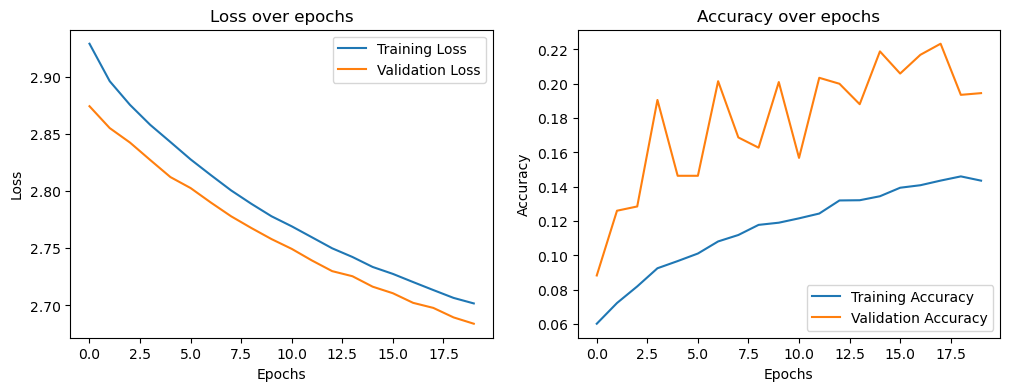

In [11]:
# Acceder a los datos de pérdida y precisión
loss = history.history['loss']
val_loss = history.history['val_loss']
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

# Graficar la pérdida del modelo
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Graficar la precisión del modelo
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

In [12]:
epochs = list(range(1, 20))

loss = history.history['loss']
val_loss = history.history['val_loss']
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']


data = {
    'Epoch': 20,
    'Trainning Loss': loss,
    'Validation Loss': val_loss,
    'Training Accuracy': accuracy,
    'Validation  Accuracy': val_accuracy
}
df = pd.DataFrame(data)

# Imprimir la tabla
print(df)

    Epoch  Trainning Loss  Validation Loss  Training Accuracy  \
0      20        2.928769         2.874148           0.060237   
1      20        2.896027         2.855033           0.072297   
2      20        2.875367         2.842403           0.081969   
3      20        2.857908         2.827177           0.092541   
4      20        2.842866         2.812219           0.096726   
5      20        2.827661         2.802592           0.101128   
6      20        2.813936         2.789952           0.108166   
7      20        2.800572         2.777951           0.111917   
8      20        2.788871         2.767706           0.117808   
9      20        2.777936         2.757995           0.119079   
10     20        2.769153         2.749440           0.121621   
11     20        2.759558         2.739280           0.124411   
12     20        2.749935         2.729978           0.132037   
13     20        2.742373         2.725543           0.132161   
14     20        2.733648

In [13]:
# Accuracy final en entrenamiento
val_loss = history.history['val_loss'][-1]

In [14]:
print('Perdida final en Train:', history.history['loss'][-1])
print("Pérdida final en Validation:", history.history['val_loss'][-1])


print("Accuracy final en Train:", history.history['accuracy'][-1])
print("Accuracy final en Validation:", history.history['val_accuracy'][-1])

Perdida final en Train: 2.701768636703491
Pérdida final en Validation: 2.6840293407440186
Accuracy final en Train: 0.1435701847076416
Accuracy final en Validation: 0.19454094767570496


In [15]:
test_df.Planta_Estado = test_df.Planta_Estado.astype('str')

test_generator =  datagen.flow_from_dataframe(test_df,
                         directory = data_dir,
                         x_col = image_id,
                         y_col = categoria,
                         target_size = (image_height,image_width),
                         batch_size = batch_size,
                         class_mode = "categorical")

Found 12601 validated image filenames belonging to 18 classes.


In [16]:
# -------------------------
# 1. Obtener predicciones completas para test
# -------------------------
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_generator.classes

394/394 ━━━━━━━━━━━━━━━━━━━━ 178s 450ms/step


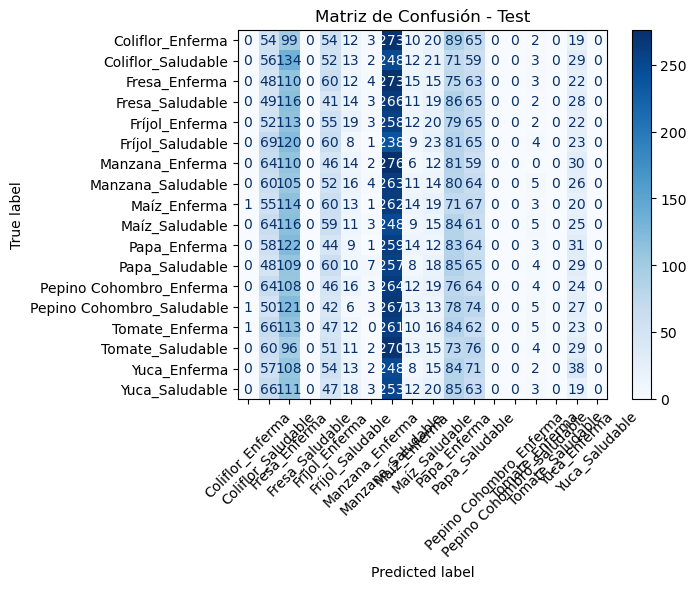

In [17]:
# -------------------------
# 2. Matriz de Confusión
# -------------------------
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=test_generator.class_indices.keys())
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Matriz de Confusión - Test")
plt.show()

In [18]:
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay

accuracy = accuracy_score(y_true, y_pred)
print(f"Test Accuracy: {accuracy:.4f}")

Test Accuracy: 0.0567


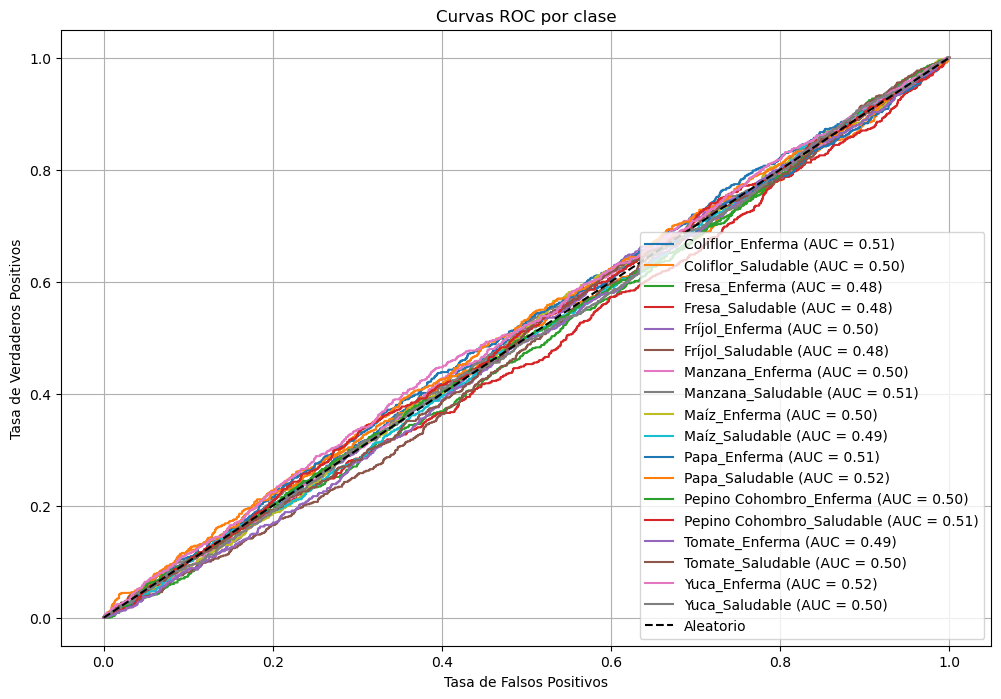

In [19]:
from sklearn.metrics import roc_curve, auc
from tensorflow.keras.utils import to_categorical


# 3. Convertir etiquetas reales a one-hot
n_classes = y_pred_probs.shape[1]
y_true_onehot = to_categorical(y_true, num_classes=n_classes)

# 4. Calcular ROC y AUC por clase
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_onehot[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 5. Obtener nombres de clase
class_names = list(test_generator.class_indices.keys())

# 6. Graficar curvas ROC
plt.figure(figsize=(12, 8))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Aleatorio')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curvas ROC por clase')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [20]:
from sklearn.metrics import roc_auc_score

# AUC macro (promedio de clases, todas igual de importantes)
auc_macro = roc_auc_score(y_true_onehot, y_pred_probs, average='macro')

# AUC micro (promedia sobre todas las instancias)
auc_micro = roc_auc_score(y_true_onehot, y_pred_probs, average='micro')

print(f"AUC Macro promedio: {auc_macro:.4f}")
print(f"AUC Micro promedio: {auc_micro:.4f}")

AUC Macro promedio: 0.4998
AUC Micro promedio: 0.5008


In [21]:
from sklearn.metrics import f1_score
# Asegúrate de tener esto:
# y_pred = np.argmax(y_pred_probs, axis=1)
# y_true = test_generator.classes

# Accuracy
accuracy = accuracy_score(y_true, y_pred)

# F1 Scores
f1_macro = f1_score(y_true, y_pred, average='macro')
f1_micro = f1_score(y_true, y_pred, average='micro')
f1_weighted = f1_score(y_true, y_pred, average='weighted')

print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score (macro): {f1_macro:.4f}")
print(f"F1 Score (micro): {f1_micro:.4f}")
print(f"F1 Score (weighted): {f1_weighted:.4f}")

# Detalle por clase
class_names = list(test_generator.class_indices.keys())
print("\nReporte de clasificación por clase:")
print(classification_report(y_true, y_pred, target_names=class_names))

Accuracy: 0.0567
F1 Score (macro): 0.0344
F1 Score (micro): 0.0567
F1 Score (weighted): 0.0344

Reporte de clasificación por clase:
                           precision    recall  f1-score   support

         Coliflor_Enferma       0.00      0.00      0.00       700
       Coliflor_Saludable       0.05      0.08      0.06       700
            Fresa_Enferma       0.05      0.16      0.08       700
          Fresa_Saludable       0.00      0.00      0.00       700
           Fríjol_Enferma       0.06      0.08      0.07       700
         Fríjol_Saludable       0.04      0.01      0.02       701
          Manzana_Enferma       0.04      0.00      0.01       700
        Manzana_Saludable       0.06      0.38      0.10       700
             Maíz_Enferma       0.07      0.02      0.03       700
           Maíz_Saludable       0.05      0.02      0.03       700
             Papa_Enferma       0.06      0.12      0.08       700
           Papa_Saludable       0.06      0.09      0.07       

In [22]:
model.save('modelo_18_MobileNetV3_Planta_Estadp_Balanceado.h5')

In [23]:
class_indices = train_generator.class_indices  # o test_generator.class_indices
index_to_class = {v: k for k, v in class_indices.items()}
print(index_to_class)
with open("index_to_class_modelo_18_MobileNetV3_Planta_Estadp_Balanceado.json", "w") as f:
    json.dump(index_to_class, f, indent=4, ensure_ascii=False)

{0: 'Maíz_Enferma', 1: 'Tomate_Saludable', 2: 'Yuca_Enferma', 3: 'Pepino Cohombro_Enferma', 4: 'Tomate_Enferma', 5: 'Manzana_Saludable', 6: 'Fresa_Enferma', 7: 'Maíz_Saludable', 8: 'Papa_Enferma', 9: 'Fresa_Saludable', 10: 'Coliflor_Enferma', 11: 'Pepino Cohombro_Saludable', 12: 'Yuca_Saludable', 13: 'Fríjol_Enferma', 14: 'Papa_Saludable', 15: 'Fríjol_Saludable', 16: 'Coliflor_Saludable', 17: 'Manzana_Enferma'}
